In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 폰트 관련 import 구문
import urllib.request
import matplotlib.font_manager as fm
import os

from collections import Counter
from wordcloud import WordCloud

In [2]:
# 1. 구글 폰트(나눔고딕) 다운로드
font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
font_path = './NanumGothic-Regular.ttf'

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
    print("✅ 나눔고딕 폰트 다운로드 완료!")

# 2. Matplotlib 폰트 매니저에 폰트 파일 직접 등록 (핵심 해결책)
fm.fontManager.addfont(font_path)

# 3. 등록된 폰트 이름 가져와서 기본 폰트로 설정
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
print(f"✅ Matplotlib 한글 폰트 설정 완료: {font_name}")

✅ Matplotlib 한글 폰트 설정 완료: NanumGothic


## Data 불러오기

In [3]:
train_df = pd.read_csv('../data/train.csv')
print(f"Train Data 개수 : {len(train_df)}")
display(train_df.head(5))

Train Data 개수 : 12457


,fname,dialogue,summary,topic
0,train_0,"#Person1#: 안녕하세요, Mr. Smith. 저는 Dr. Hawkins입니다...","Mr. Smith는 Dr. Hawkins에게 건강검진을 받으러 와서, 매년 검진 필...",건강검진
1,train_1,"#Person1#: 안녕하세요, Mrs. Parker. 잘 지내셨나요?\n#Pers...","Mrs. Parker가 Ricky와 함께 백신 접종을 위해 방문하였고, Dr. Pe...",백신 접종
2,train_2,"#Person1#: 저기요, 열쇠 세트 본 적 있어요?\n#Person2#: 어떤 ...",#Person1#은 열쇠 세트를 잃어버리고 #Person2#에게 찾는 것을 도와달라...,열쇠 분실
3,train_3,#Person1#: 너 여자친구 있는 거 왜 말 안 했어?\n#Person2#: 미...,#Person1#은 #Person2#가 여자친구가 있고 결혼할 예정이라는 사실을 말...,여자친구와의 결혼
4,train_4,"#Person1#: 안녕, 오늘 너무 멋져 보이네요. 저랑 춤 한 곡 추실래요?\n...","Malik은 Wen과 Nikki에게 춤을 제안하고, Wen은 발을 밟는 것을 감수하...",춤 제안


## 대화문 & 요약문 길이 분포 시각화 해보기 (max_length 검증)

베이스라인에서 설정한 512, 100 (encdoer, decoder 를 512 100 으로 설정한게 합당한지 체크) <br>
분포를 눈으로 직접 보면서 데이터의 95% 이상을 포함하면서도 메모리를 아낄 수 있는 최적의 max_len 을 찾아보기 위해서

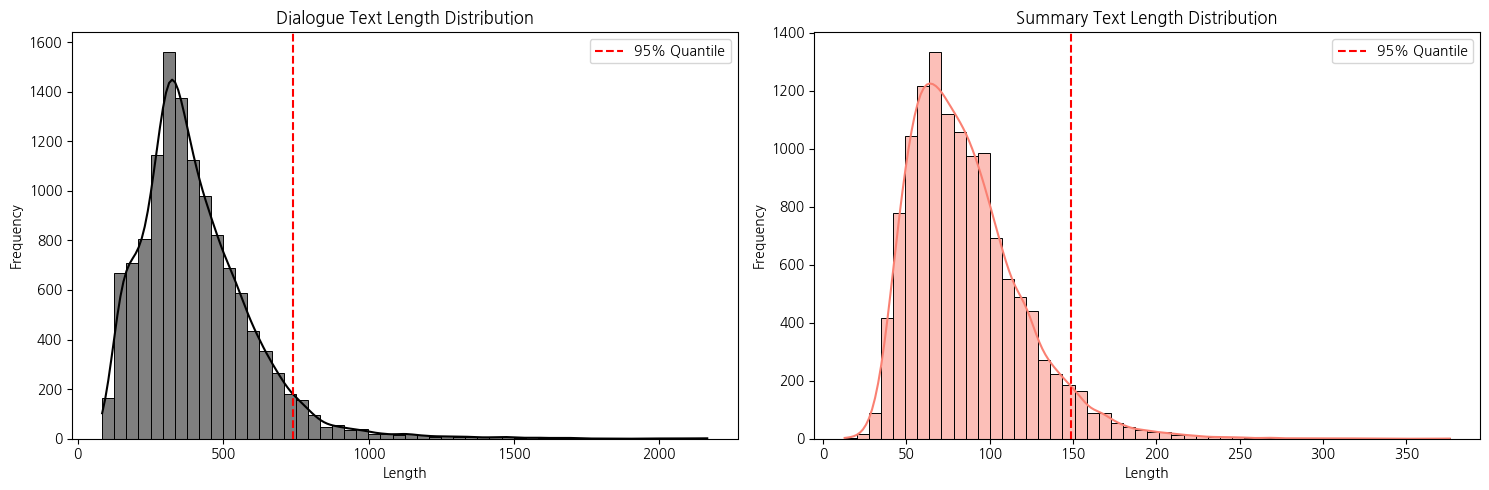

대화문 95% 커버 길이 : 742
요약문 95% 커버 길이 : 149


In [4]:
# 글자 수 기준으로 길이를 계산 
# 추후 토크나이저를 적용한 길이더 확인해야 하긴 하는데, 직관적인 확인을 위해서
train_df['dialogue_len'] = train_df['dialogue'].apply(len)
train_df['summary_len'] = train_df['summary'].apply(len)

# 시각화 (Subplot을 활용해 두 그래프를 나란히 배치)
flg, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 대화문 길이 분포
sns.histplot(train_df['dialogue_len'], bins=50, kde=True, ax=axes[0], color='black')
axes[0].set_title('Dialogue Text Length Distribution')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['dialogue_len'].quantile(0.95), color='red', linestyle='--', label='95% Quantile')
axes[0].legend()

# 2. 요약문 길이 분포
sns.histplot(train_df['summary_len'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Summary Text Length Distribution')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train_df['summary_len'].quantile(0.95), color='red', linestyle='--', label='95% Quantile')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"대화문 95% 커버 길이 : {train_df['dialogue_len'].quantile(0.95):.0f}")
print(f"요약문 95% 커버 길이 : {train_df['summary_len'].quantile(0.95):.0f}")

## 숨겨진 특수 토큰 (Special Tokens) 및 화자 빈도 시각화

베이스라인에서 #...# 형태의 토큰 6개를 하드코딩 했는데, DataSet 전체를 스캔해가지고 # 과 # 사이에 있는 모든 고유 패턴을 추출해보는거임. <br>
그리고 얼마나 자주 등장하는지 시각화 해보고 모델 사전에 추가해야 할 누락된 스페셜 토큰을 찾아보기

/tmp/ipykernel_330834/2652843699.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='token', data=token_df.head(15), palette='viridis')


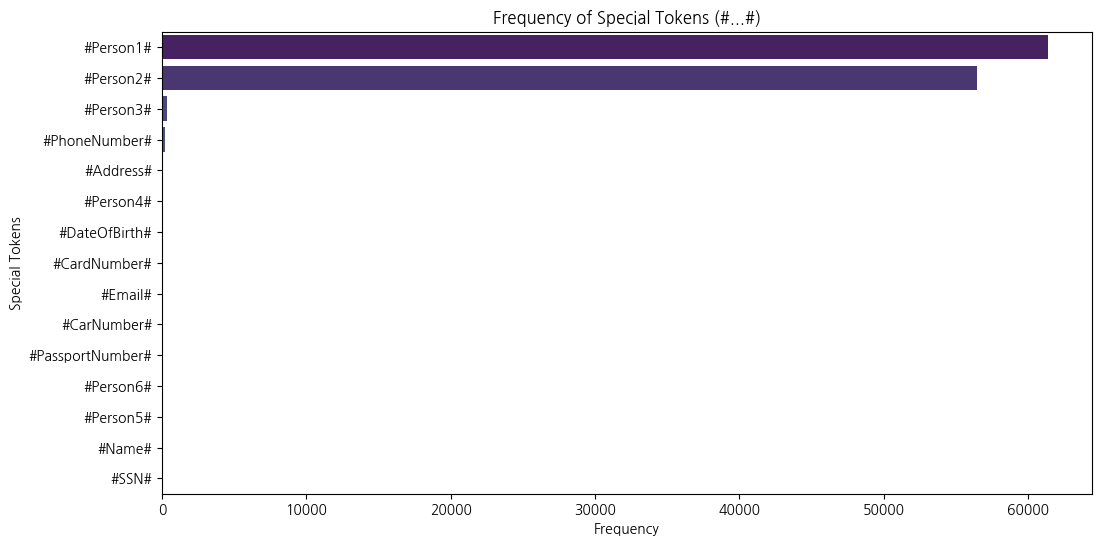

베이스라인에서 정의되지 않은 새로운 토큰들 : {'#Person6#', '#Liliana#', '#Kristin#', '#SSN#', '#Name#', '#Email#', '#PersonName#', '#Person5#', '#CarNumber#', '#DateOfBirth#', '#Price#', '#Alex#', '#Person7#', '#CardNumber#', '#Bob#', '#Person4#'}


In [5]:
# '#' 문자로 둘러싸인 모든 패턴을 찾아보기
def extract_special_tokens(text):
    return re.findall(r'#[a-zA-Z0-9]+#', str(text))

# 전체 대화문에서 특수 토큰 추출
all_tokens = train_df['dialogue'].apply(extract_special_tokens).sum()
token_counts = Counter(all_tokens)

# DataFrame 으로 변환해서 정렬
token_df = pd.DataFrame.from_dict(token_counts, orient='index', columns=['count']).reset_index()
token_df.columns = ['token', 'count']
token_df = token_df.sort_values(by='count', ascending=False)

# 시각화 해보기 : 상위 15개 특수 토큰 빈도수
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='token', data=token_df.head(15), palette='viridis')
plt.title('Frequency of Special Tokens (#...#)')
plt.xlabel('Frequency')
plt.ylabel('Special Tokens')
plt.show()

# 새로운 토큰이 있는지도 한번 봐보자
baseline_tokens = ['#Person1#', '#Person2#', '#Person3#', '#PhoneNumber#', '#Address#', '#PassportNumber#']
discovered_tokens = token_df['token'].tolist()
missing_in_baseline = set(discovered_tokens) - set(baseline_tokens)
print(f"베이스라인에서 정의되지 않은 새로운 토큰들 : {missing_in_baseline}")

## 주요 명사 랑 키워드 워드클라우드 (고유명사는 보존 전략)

대회 목표 중에 소개된게 '고유명사 보존' 이였음 <br>
그래서 어떤 주제의 대화가 오고 가는지, 어떤 명사들이 주로 쓰이는지 거시적으로 파악하는게 중요할 것 같다는 생각

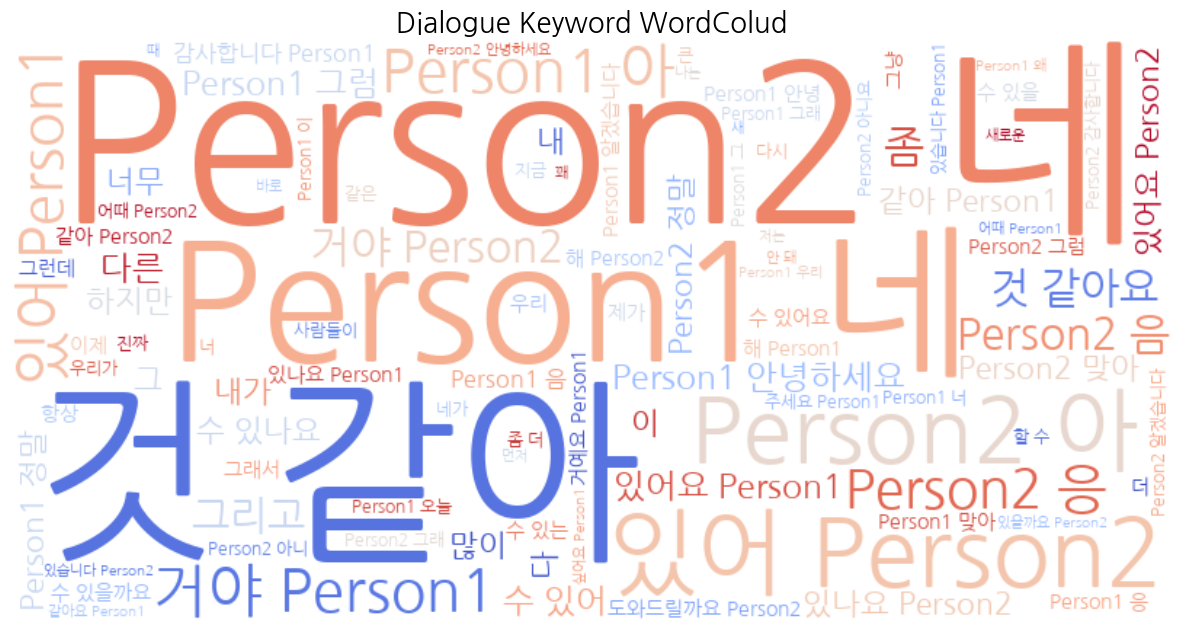

In [6]:
# 대화문 데이터 텍스트를 통합
text_corpus = " ".join(train_df['dialogue'].astype(str))

# 워드클라우드 객체 생성
font_path = './NanumGothic-Regular.ttf'

wordcloud=WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color='white',
    colormap='coolwarm',
    max_words=100
).generate(text_corpus)

# 시각화
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')     # 축제거
plt.title('Dialogue Keyword WordColud', fontsize=20)
plt.show()

## 결측치 확인하기

== 컬럼별 결측치 개수 ==
fname           0
dialogue        0
summary         0
topic           0
dialogue_len    0
summary_len     0
dtype: int64
전체 데이터 개수 : 12457


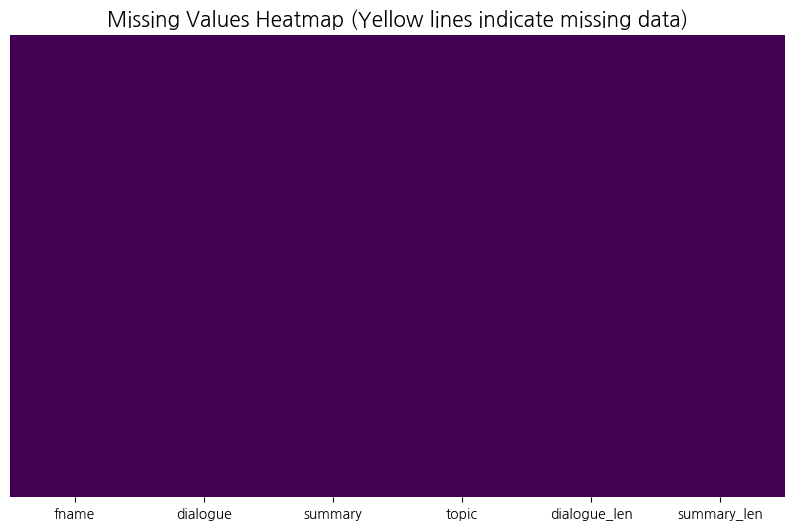

결측치가 존재하지 않습니다.


In [7]:
# 1. 컬럼별 결측치 개수 확인
print("== 컬럼별 결측치 개수 ==")
missing_counts = train_df.isnull().sum()
print(missing_counts)
print(f"전체 데이터 개수 : {len(train_df)}")

# 2. 결측치 분포 시각화
plt.figure(figsize=(10, 6))
# 결측치 인 곳은 노란색 이고, 정상 데이터는 보라색(어두운색)으로 표현해보기
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow lines indicate missing data)', fontsize=15)
plt.show()

# 3. 결측치가 포함된 실제 데이터 눈으로 확인하기
missing_rows = train_df[train_df.isnull().any(axis=1)]

if len(missing_rows) > 0:
    print("== 🚨 결측치가 포함된 데이터 샘플 (최대 5개) ==")
    display(missing_rows.head())
else:
    print("결측치가 존재하지 않습니다.")

## 요약문 종결어미 분석 

"~했다" 이런거랑 "~해요" 라는게 조금 섞여 있으면 학습과정에서 헷갈릴 수 있다고 판단 <br>
PPT 11 Page - 4번문항 '관찰자의 관점에서 작성' 을 유의하여 요약문 종결어미를 분석

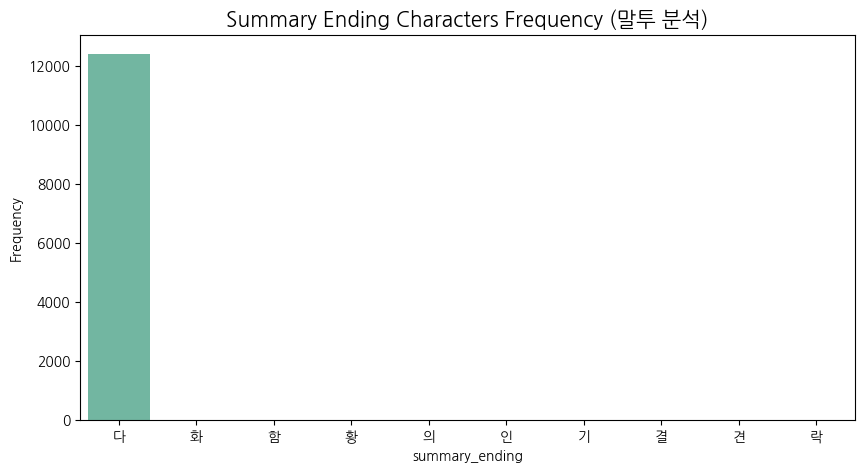

요약문 종결어미 Top 10
summary_ending
다    12428
화       10
함        5
황        3
의        2
인        1
기        1
결        1
견        1
락        1
Name: count, dtype: int64


In [8]:
# 요약문의 마지막 글자를 추출
def get_last_char(text):
    # 문장 끝에 오는 한글 문자를 하나만 추출 (ex: 방문하였다. -> 다)
    match = re.search(r'([가-힣])[.\s]*$', str(text))
    if match:
        return match.group(1)
    return '기타'

train_df['summary_ending'] = train_df['summary'].apply(get_last_char)
ending_counts = train_df['summary_ending'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=ending_counts.index, y=ending_counts.values, palette='Set2', hue=ending_counts.index, legend=False)
plt.title('Summary Ending Characters Frequency (말투 분석)', fontsize=15)
plt.ylabel('Frequency')
plt.show()

print("요약문 종결어미 Top 10")
print(ending_counts)

💡 인사이트 및 방향성 <br>

압도적으로 '다' 로 끝나는게 많음 (대회에서 요구하는 부분이랑 맞아 떨어짐) <br>
그래서 나중에 추론 과정에서 ~요 나 ~음 이런식으로 ~다 가 아닌 형식으로 문장을 끝내면 ~다 식으로 강제 하드코딩 하는 과정도 생각해보면 좋을 것 같음

## 핑퐁체크

모델 입장에서 A 랑 B 가 대화를 한번씩 주고 받는데 문장이 엄청 긴거랑 <br>
A 랑 B 가 단답식으로 여러번 대화를 주고 받는 걸 학습하고 해석하는데 엄청 헷갈린다고 함 <br> <br>

그래서 화자가 몇 번이나 교체되는지 턴 수를 보는게 좋다고 판단

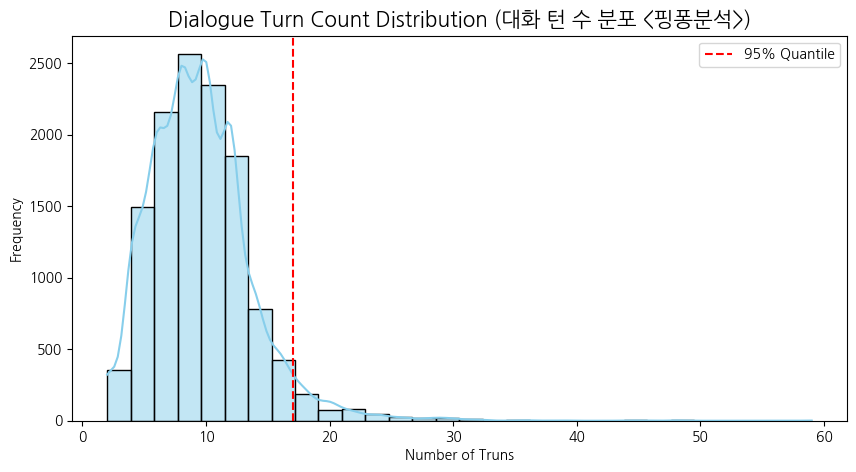

대화 턴 수 통계
count    12457.000000
mean         9.524123
std          4.177472
min          2.000000
25%          7.000000
50%          9.000000
75%         12.000000
max         59.000000
Name: turn_count, dtype: float64


In [9]:
# 대화문 안에 '#..#' (화자 표현) 형태의 태그 개수를 카운트해서 턴 수를 측정 (핑퐁측정)
train_df['turn_count'] = train_df['dialogue'].apply(lambda x: len(re.findall(r'#[a-zA-Z0-9]', str(x))))

plt.figure(figsize=(10, 5))
sns.histplot(train_df['turn_count'], bins=30, kde=True, color='skyblue')
plt.title('Dialogue Turn Count Distribution (대화 턴 수 분포 <핑퐁분석>)', fontsize=15)
plt.xlabel('Number of Truns')
plt.ylabel('Frequency')
# 95% 커버 턴 수 표시
plt.axvline(train_df['turn_count'].quantile(0.95), color='red', linestyle='--', label='95% Quantile')
plt.legend()
plt.show()

print("대화 턴 수 통계")
print(train_df['turn_count'].describe())

💡 인사이트 및 방향성 <br>

평균이 9.5 정도의 턴이 소요되는 것 같은데, 근데 59번이나 핑퐁한 극단적 이상치가 존재 <br>
오른쪽으로 꼬리가 길어진 그래프 형태인데, 여기서 한 95% 넘어가는 핑퐁대화라면 문맥의 방향성을 잃어버릴 수도 있을 것 같음 <br> <br>

턴 수가 20 이상인 긴 대화들만 따로 모아가지고 모델이 요약을 잘하는지 심층 분석이 필요할 것 같음 <br>
약점 발견시 max_length 를 늘리거나 하이퍼파라미터 조정으로 수치 조절

## 단어 겹침 비율 분석

원본 대화에 있는 단어가 요약문에 그대로 등장하는 비율을 보는데 <br>
이게 정답 데이터가 단순히 본문의 중요한 문장을 복사 붙여넣기 했는지 사람의 머리를 거쳐 완전히 새로운 단어로 된건지 데이터 성향을 파악 <br> <br>

겹침 비율이 높으면 모델링에서 대화문에서 중요한 단어를 가리키는데 Focus 를 두면 좋을 것 같음. <br>
반대로 비율이 낮으면 모델이 스스로 단어사전을 찾아가면서 새로운 문장을 창조하게끔 유도

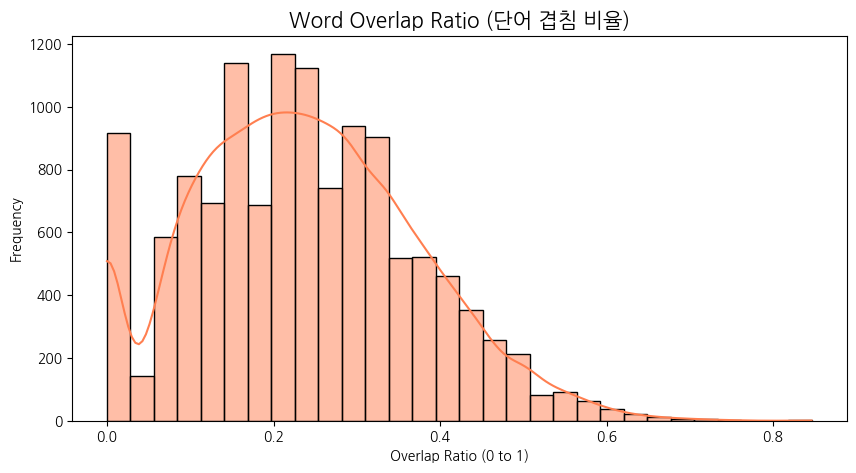

단어 겹침 비율 통계
count    12457.000000
mean         0.236134
std          0.135050
min          0.000000
25%          0.137931
50%          0.230769
75%          0.333333
max          0.846154
Name: overlap_ratio, dtype: float64


In [10]:
def calc_word_overlap(row):
    dial_words = set(str(row['dialogue']).split())
    summ_words = set(str(row['summary']).split())
    if len(summ_words) == 0: return 0
    # 요약문 단어 중 대화문에도 존재하는 단어의 비율
    overlap = len(dial_words.intersection(summ_words))
    return overlap / len(summ_words)

train_df['overlap_ratio'] = train_df.apply(calc_word_overlap, axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(train_df['overlap_ratio'], bins=30, kde=True, color='coral')
plt.title('Word Overlap Ratio (단어 겹침 비율)', fontsize=15)
plt.xlabel('Overlap Ratio (0 to 1)')
plt.ylabel('Frequency')
plt.show()

print("단어 겹침 비율 통계")
print(train_df['overlap_ratio'].describe())

💡 인사이트 및 방향성 <br>

단어 겹침 비율이 높지가 않음 즉 '복사/붙여넣기' 형태가 아니라 모델이 요약할 때 단어 자체를 사전을 뒤져가면서 새로운 단어로 탄생 시켜야 함 <br>
모델한테 생성의 자유도를 높이는 방향으로 나아가보기 (동일한 단어 반복 금지 형태 부여)

## 형태소 분석기 (KoNLPy) 를 통과했을 때 어떻게 쪼개지는가?

리더보드 제출형식에 'Rouge 점수를 "형태소 단위"로 쪼개서 계산' <br>
그래가지고 형태소 분석기를 통과했을 때 어떻게 쪼개지는지 한번 파악해야됨 <br> <br>

내가 위에 주제를 달아주고, #..# 같은 특수 기호를 처리해서 이걸 이상하게 쪼개버리면 Score 하락 발생 가능성이 존재하기 때문에

In [11]:
try:
    from konlpy.tag import Okt
    okt = Okt()

    # 테스트할 가상의 가공 DataSample
    sample_text = "[주제: 건강검진] #Person1#: 안녕하세요, 제 이메일은 #Email# 입니다."

    print("원본 가공 텍스트 : ", sample_text)
    print("형태소 분석기 (Okt) : 통과 후 쪼개고 난 결과 : ", okt.morphs(sample_text))

except ImportError:
    print("🚨 KoNLPY 라이브러리 설치 필요")

원본 가공 텍스트 :  [주제: 건강검진] #Person1#: 안녕하세요, 제 이메일은 #Email# 입니다.
형태소 분석기 (Okt) : 통과 후 쪼개고 난 결과 :  ['[', '주제', ':', '건강검진', ']', '#Person1', '#:', '안녕하세요', ',', '제', '이메일', '은', '#Email', '#', '입니다', '.']


💡 인사이트 및 방향성 <br>

우려했던 점 그대로 형태소 분석기에 돌려보니 우리가 붙여 본 Topic 이나 #..# 형태가 다 짤려버림 <br>
이게 Score 하락에 원인이 될 수 있으니 <br>

1. [주제: 건강검진] 이런 부분은 모델이 읽기만 하고, 절대 요약문에 쓰지 않도록 고정
2. -> 파생 개념인데 [ ] 가 포함되면 무조건 삭제하는 후처리 파이프라인을 추가 (근데 #..# 은 요약문에도 들어가야 할 사항 일 수도 있으니 얘는 삭제처리 불가능)

## Topic 별 Data 분포 개수 확인

In [ ]:
# 1. 훈련 데이터 불러오기 (경로 확인!)
train_df = pd.read_csv('../Data/train_processed.csv')

# 2. 'topic' 컬럼의 데이터별 개수를 세고 내림차순 정렬
topic_counts = train_df['topic'].value_counts()

print("Train 데이터 토픽 분포 확인")
print(f"총 고유 토픽 수: {len(topic_counts)}개\n")

# 3. 전체 토픽과 개수 깔끔하게 출력하기
print("--- 토픽별 데이터 개수 ---")
for topic, count in topic_counts.items():
    print(f"[{topic}]: {count}개")

# 4. 데이터 증강이 시급한 '하위 10개' 토픽 자동 추출
weak_topics = topic_counts.tail(10).index.tolist()
print("\n 데이터가 가장 부족한 하위 10개 토픽:")
print(weak_topics)